In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator

In [2]:
## -- load observed spectrum:
dat_wavelengths, dat_spec, dat_specerr = np.loadtxt("./data/stellar_fits/V1298Tau_NIRISSobs2_fluxcal_medianspectrum.txt", skiprows=1, unpack=True)

## -- load best-fit 3-component model
l = np.load('./data/stellar_fits/3comp_models_JWSTgrid.npz')
mod_wavelengths = l['waves']
mod_full = l['yfull']
mod_phot = l['yphot']
mod_cool = l['ycool']
mod_hot = l['yhot']

## -- covering fractions:
fcool = 0.19948552357508584
fhot = 0.3324712072431044
fphot = 1. - (fcool+fhot)

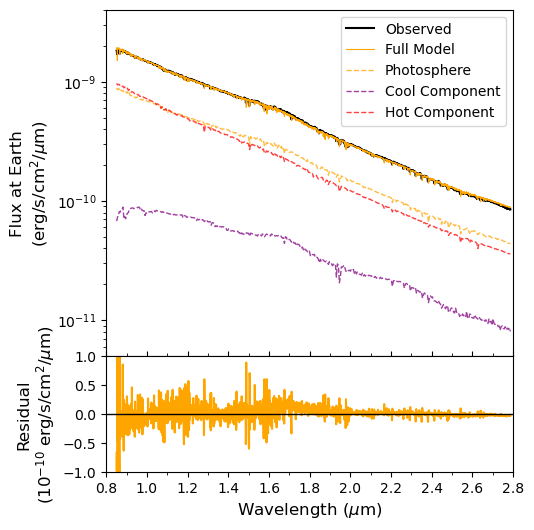

In [3]:
## -- paper figure:
fig, ax = plt.subplots(figsize=(5.25,6), nrows=2, sharex=True, gridspec_kw={'height_ratios':[3,1]})
plt.subplots_adjust(hspace=0.)
ax[0].plot(dat_wavelengths, dat_spec, c='black', zorder=1, label=r'Observed')
ax[0].plot(mod_wavelengths, mod_full, c='orange', ls='solid', lw=0.8, zorder=3, label='Full Model')
ax[0].plot(mod_wavelengths[::5], fphot*mod_phot[::5], c='orange', ls='--', lw=1, alpha=0.75, zorder=2, label='Photosphere')
ax[0].plot(mod_wavelengths[::5], fcool*mod_cool[::5], c='purple', ls='--', lw=1, alpha=0.75, zorder=2, label='Cool Component')
ax[0].plot(mod_wavelengths[::5], fhot*mod_hot[::5], c='red', ls='--', lw=1, alpha=0.75, zorder=2, label='Hot Component')
ax[0].set_yscale('log')
ax[0].set_ylabel('Flux at Earth\n'+r'(erg/s/cm$^2$/$\mu$m)', fontsize=12)
ax[0].legend(loc='best', fontsize=10)
ax[0].set_xlim(0.8, 2.8)
ax[0].set_ylim(5e-12,4e-9)
ax[0].tick_params(axis='x', which='both', direction='in')


ax[1].axhline(0., c='black', lw=1, zorder=10)
ax[1].plot(dat_wavelengths, (dat_spec-mod_full)*1.e10, c='orange')
ax[1].set_ylabel('Residual\n'+r'(10$^{-10}$ erg/s/cm$^2$/$\mu$m)', fontsize=12)
ax[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[1].set_ylim(-1,1)
ax[1].xaxis.set_major_locator(MultipleLocator(0.2))
ax[1].xaxis.set_minor_locator(MultipleLocator(0.1))

plt.savefig('./figures/Figure4.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/Figure4.pdf', format='PDF', dpi=600, bbox_inches='tight')
plt.show()